In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/saudi_food_delivery_market_2023_2025.csv')
df.head()

,Date,Platform,Monthly_Orders,Active_Users,New_Users,Average_Order_Value_SAR,Revenue,App_Downloads,Customer_Retention_Rate,Market_Share,Marketing_Spend_SAR
0,2023-01,HungerStation,13.16,42112000,4606000,72.0,947.52,6448399,72.00,47.0,93614976
1,2023-01,Jahez,10.08,32256000,3527999,75.0,756.00,4939199,72.00,36.0,71366400
2,2023-01,Ninja,4.76,15232000,1666000,70.0,333.20,2332400,72.00,17.0,28921760
3,2023-01,Keeta,0.00,0,0,68.0,0.00,0,72.00,0.0,0
4,2023-02,HungerStation,13.19,42224000,4618249,72.0,950.04,6465549,72.22,46.8,93787948


In [6]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     144 non-null    object 
 1   Platform                 144 non-null    object 
 2   Monthly_Orders           144 non-null    float64
 3   Active_Users             144 non-null    int64  
 4   New_Users                144 non-null    int64  
 5   Average_Order_Value_SAR  144 non-null    float64
 6   Revenue                  144 non-null    float64
 7   App_Downloads            144 non-null    int64  
 8   Customer_Retention_Rate  144 non-null    float64
 9   Market_Share             144 non-null    float64
 10  Marketing_Spend_SAR      144 non-null    int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 12.5+ KB


,Monthly_Orders,Active_Users,New_Users,Average_Order_Value_SAR,Revenue,App_Downloads,Customer_Retention_Rate,Market_Share,Marketing_Spend_SAR
count,144.000000,1.440000e+02,1.440000e+02,144.000000,144.000000,1.440000e+02,144.000000,144.000000,1.440000e+02
mean,8.152361,2.608714e+07,2.853281e+06,73.743333,611.627083,3.994593e+06,75.888889,24.905347,5.702544e+07
std,4.715585,1.508960e+07,1.650425e+06,3.375057,359.861025,2.310595e+06,2.316856,14.447350,3.537103e+07
min,0.000000,0.000000e+00,0.000000e+00,68.000000,0.000000,0.000000e+00,72.000000,0.000000,0.000000e+00
25%,4.787500,1.532372e+07,1.676032e+06,71.595000,356.595000,2.346445e+06,73.945000,15.090000,3.072911e+07
50%,8.580000,2.745659e+07,3.003064e+06,73.640000,647.115000,4.204290e+06,75.890000,24.810000,5.891525e+07
75%,12.517500,4.004836e+07,4.380289e+06,75.510000,930.810000,6.132404e+06,77.835000,37.225000,8.970863e+07
max,16.600000,5.310741e+07,5.808623e+06,80.250000,1236.740000,8.132072e+06,79.780000,47.000000,1.207057e+08


In [7]:
df['Revenue_Check'] = df['Monthly_Orders'] * df['Average_Order_Value_SAR']
df['Difference'] = df['Revenue'] - df['Revenue_Check']
df[['Platform','Date','Difference']].head()

,Platform,Date,Difference
0,HungerStation,2023-01,0.00
1,Jahez,2023-01,0.00
2,Ninja,2023-01,0.00
3,Keeta,2023-01,0.00
4,HungerStation,2023-02,0.36


In [8]:
market_size = df.groupby('Date')['Revenue'].sum().reset_index()
market_size.head()

,Date,Revenue
0,2023-01,2036.72
1,2023-02,2048.91
2,2023-03,2514.53
3,2023-04,2529.34
4,2023-05,2085.35


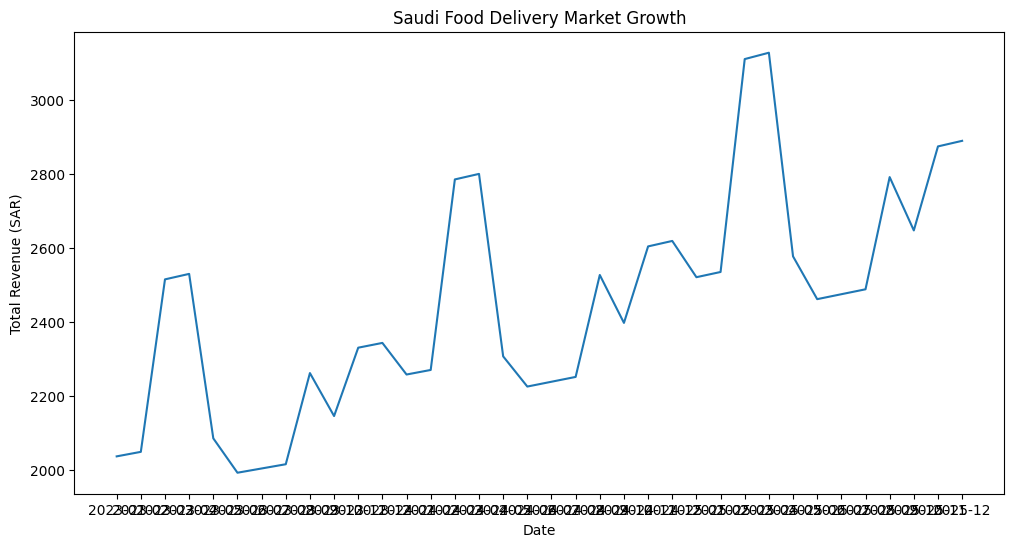

In [10]:
plt.figure(figsize=(12,6))
plt.plot(market_size['Date'], market_size['Revenue'])
plt.title('Saudi Food Delivery Market Growth')
plt.xlabel('Date')
plt.ylabel('Total Revenue (SAR)')
plt.show()

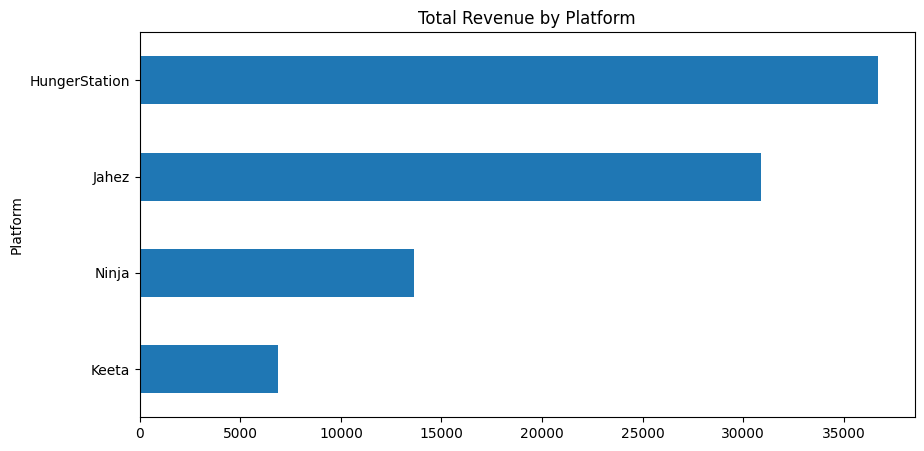

In [12]:
platform_revenue = df.groupby('Platform')['Revenue'].sum().sort_values()
platform_revenue.plot(kind='barh', figsize=(10,5))
plt.title('Total Revenue by Platform')
plt.show()

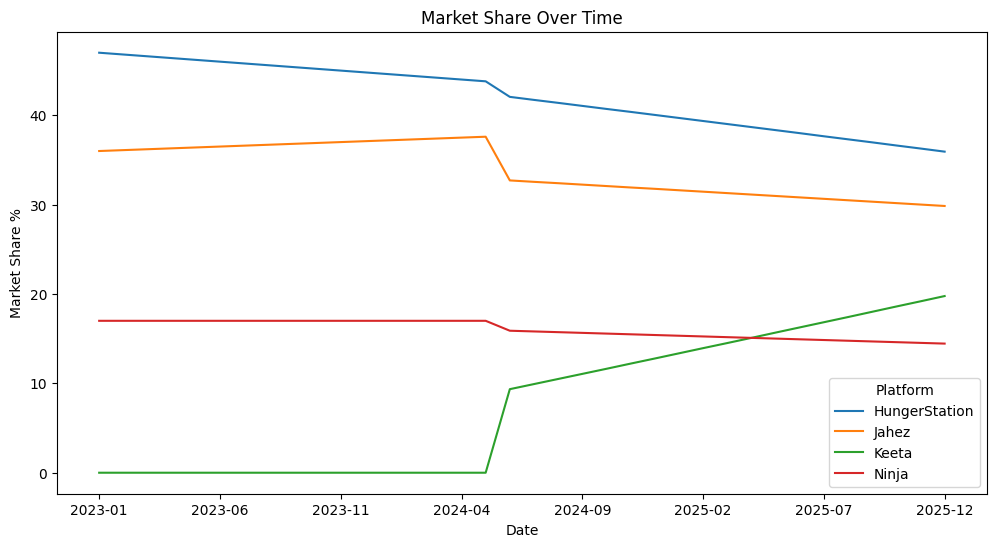

In [14]:
pivot_share = df.pivot(index='Date', columns='Platform', values='Market_Share')
pivot_share.plot(figsize=(12,6))
plt.title('Market Share Over Time')
plt.ylabel('Market Share %')
plt.show()

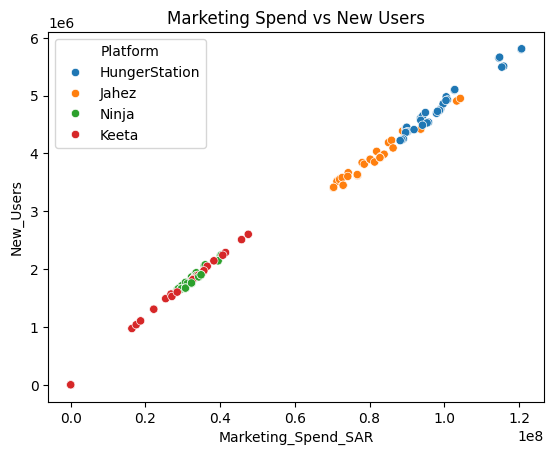

In [15]:
sns.scatterplot(
data=df,
x='Marketing_Spend_SAR',
y='New_Users',
hue='Platform'
)
plt.title('Marketing Spend vs New Users')
plt.show()

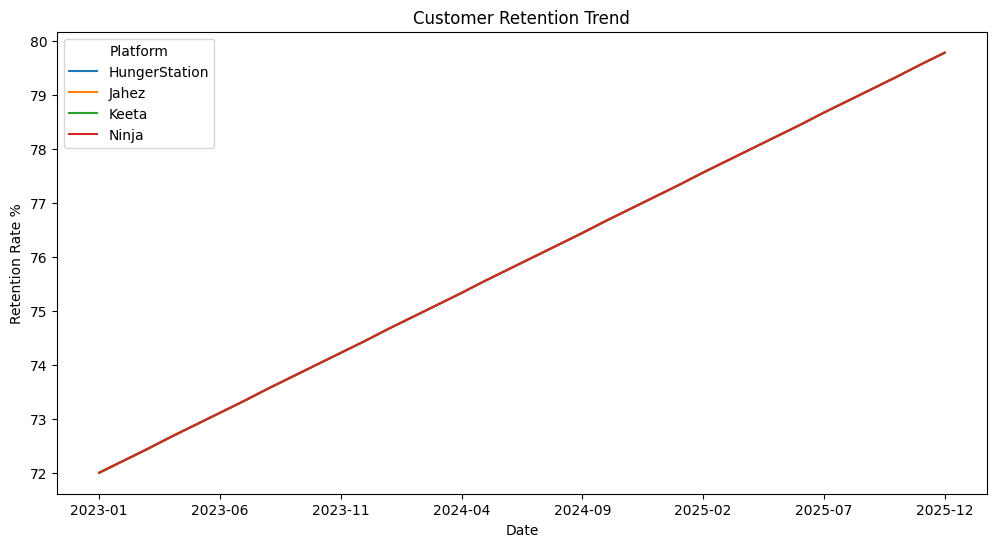

In [16]:
retention_trend = df.groupby(['Date','Platform'])['Customer_Retention_Rate'].mean().unstack()
retention_trend.plot(figsize=(12,6))
plt.title('Customer Retention Trend')
plt.ylabel('Retention Rate %')
plt.show()

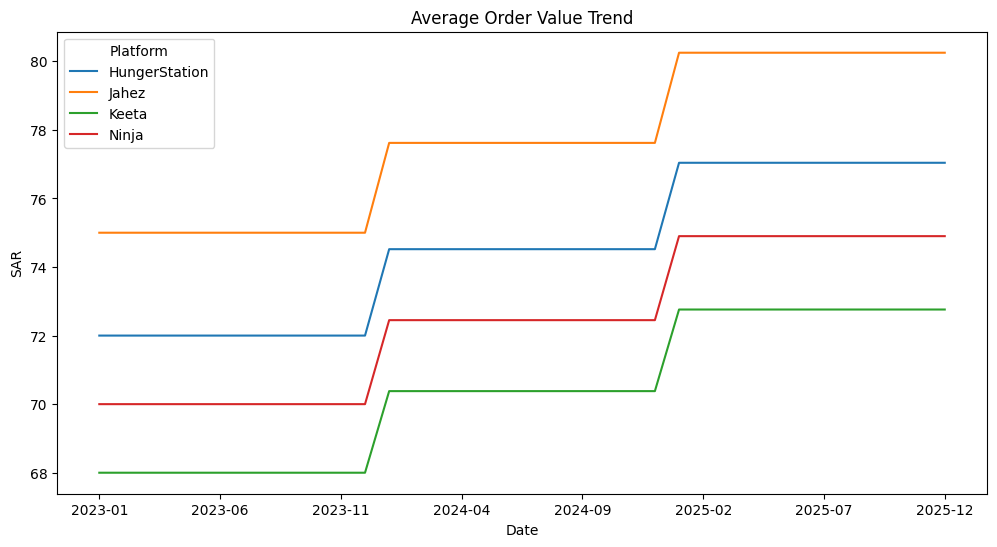

In [17]:
aov_trend = df.pivot(index='Date', columns='Platform', values='Average_Order_Value_SAR')
aov_trend.plot(figsize=(12,6))
plt.title('Average Order Value Trend')
plt.ylabel('SAR')
plt.show()

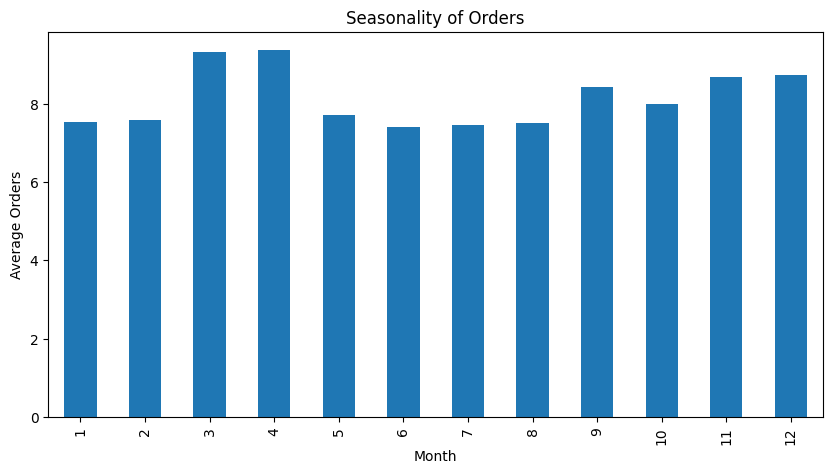

In [19]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
monthly_orders = df.groupby('Month')['Monthly_Orders'].mean()
monthly_orders.plot(kind='bar', figsize=(10,5))
plt.title('Seasonality of Orders')
plt.ylabel('Average Orders')
plt.show()

In [20]:
growth = df.groupby('Platform')['Monthly_Orders'].agg(['first','last'])
growth['Growth_%'] = ((growth['last'] - growth['first']) / growth['first'])
growth.sort_values('Growth_%', ascending=False)

,first,last,Growth_%
Platform,,,
Keeta,0.00,7.43,inf
Ninja,4.76,5.43,0.140756
Jahez,10.08,11.22,0.113095
HungerStation,13.16,13.51,0.026596
